# Predicting Titled Tuesday Game Outcomes (White's perspective)

**Task.** For each Titled Tuesday blitz game, predict White's result —
**white win / draw / white loss** — using *only information available before the
game starts*. The leakage-safe data collection and feature engineering live in
`src/`; this notebook is the modeling + evaluation deliverable and reuses them.

**Approach.** Outcomes are *ordinal* (a draw sits between a loss and a win), so
instead of a flat 3-class model we use the **cumulative / Frank–Hall**
decomposition: two binary XGBoost classifiers whose predictions are recombined
into a proper 3-class distribution. Model selection uses **leave-one-event-out**
cross-validation over the training events; we evaluate once on a held-out
*future* event and benchmark against the natural baseline — *the higher-rated
player wins*.

> **Headline finding.** A first pass scored a suspicious **93% test accuracy**.
> Section 3 is a **leakage audit** that traces this to Chess.com's game-object
> ratings being *post-game*: two prior-rating features let the model recover each
> result by differencing. We removed them at the source. The honest model lands
> near the baseline (~0.71 accuracy, macro-F1 ~0.50) with a genuine *probabilistic*
> edge on decisive games (win/loss AUC ≈ 0.82) but **essentially no draw signal**
> (draw AUC ≈ 0.54) — draws are close to irreducible from pre-game information.
> Catching the leak, and reporting the sober result, is the point of the exercise.

### Contents
0. Setup, data, target, splits & modeling utilities
1. Dataset overview / EDA
2. Rating & Elo EDA
3. **Leakage audit** (proof + when + before/after)
4. Cold-start analysis
5. Baseline: higher-rated player wins
6. Cross-validated model selection
7. Final ordinal model
8. Evaluation (validation + test)
9. Feature importance
10. Sensitivity analyses
11. Writeup & next steps

## 0. Setup, data, target, splits & modeling utilities

We import the **existing** feature layer from `src/`. `build_feature_matrix`
refuses to run on any frame that still carries a post-game column (`pgn`, `fen`,
`eco`, `end_time`, `termination`, result codes), so leakage protection is
enforced at the source. The notebook rebuilds the modeling matrix from
`data/processed/base_dataset.csv` so it is reproducible from the raw cache.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
RNG = 42
np.random.seed(RNG)

REPO = Path.cwd()
while not (REPO / "pyproject.toml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))

from features import build_feature_matrix          # noqa: E402
from features.build import LEAKY_COLUMNS           # noqa: E402
from features.rating import elo_expected_score     # noqa: E402
from events import EVENTS, SPLIT_BY_EVENT, TARGET_ROLES  # noqa: E402

print("Repo root:", REPO)

Repo root: /Users/inaki/Workspace/Repos/chess-outcome-prediction


In [2]:
# Rebuild the (leak-free) modeling matrix from the base dataset.
base = pd.read_csv(REPO / "data" / "processed" / "base_dataset.csv")
feat = build_feature_matrix(base)
feat["split"] = feat["event"].map(SPLIT_BY_EVENT)
df = feat[feat["split"].isin(TARGET_ROLES)].reset_index(drop=True)

# Guardrails: no post-game columns, and the two rating-level prior features that
# leaked (Section 3) must be gone from the shipped feature layer.
assert not (LEAKY_COLUMNS & set(df.columns)), "post-game column present!"
assert not [c for c in df.columns
            if c in {"prior_last_or_pregame_rating_diff",
                     "prior_rolling3_rating_diff"}], "leaky rating feature present!"

print(f"Modeling rows: {len(df):,}  |  columns: {df.shape[1]}")
df.head(3)

Modeling rows: 9,827  |  columns: 38


,event,tournament_url,tournament_start_time,round,group,game_url,white_username,black_username,white_uuid,black_uuid,...,recent_last5_score_rate_diff,recent_last5_draw_rate_diff,recent_last5_avg_opponent_rating_diff,current_color_last5_score_rate_diff,prior_event_score_rate_diff,h2h_games,h2h_white_score_rate,h2h_same_color_games,h2h_same_color_white_score_rate,split
0,tt_2026_02_10,https://www.chess.com/tournament/live/titled-t...,1770739200,1,1,https://www.chess.com/game/live/165052787661,umuterdemgunduz,hikaru,0016479a-a347-11e9-b619-7d5b9e8b8800,6f4deb88-7718-11e3-8016-000000000000,...,-0.6,0.0,-3088.2,-0.8,-0.727273,0,0.0,0,0.0,train
1,tt_2026_02_10,https://www.chess.com/tournament/live/titled-t...,1770739200,1,1,https://www.chess.com/game/live/165052787663,lachesisq,gorindeshi,ea103016-2647-11e6-8040-000000000000,af27c69c-36ef-11ee-afee-879979d51b45,...,0.3,0.6,125.6,0.5,0.202381,0,0.0,0,0.0,train
2,tt_2026_02_10,https://www.chess.com/tournament/live/titled-t...,1770739200,1,1,https://www.chess.com/game/live/165052787665,jaisankars,nikotheodorou,cb754d68-e4f6-11ef-a68a-9be73e69b3c8,4d8a88c8-4b2b-11eb-89ec-1b7cb3f4e61a,...,-0.3,-0.2,-317.4,-0.3,-0.144689,0,0.0,0,0.0,train


### Ordinal target

We encode the label on an **ordinal scale** so distance between classes is
meaningful, then derive the two **cumulative** binary targets the model learns.

| ordinal `y` | meaning   | label        |     | cumulative target | meaning                     |
|:-----------:|-----------|--------------|-----|-------------------|-----------------------------|
| 0           | black win | `white_loss` |     | `y_ge_draw = 1[y≥1]` | White does not lose      |
| 1           | draw      | `draw`       |     | `y_ge_win  = 1[y≥2]` | White wins               |
| 2           | white win | `white_win`  |     |                   |                             |

In [3]:
ORDINAL = {"white_loss": 0, "draw": 1, "white_win": 2}
CLASS_NAMES = ["black_win", "draw", "white_win"]  # index == ordinal value

df["y"] = df["target"].map(ORDINAL).astype(int)
df["y_ge_draw"] = (df["y"] >= 1).astype(int)
df["y_ge_win"] = (df["y"] >= 2).astype(int)
df[["target", "y", "y_ge_draw", "y_ge_win"]].value_counts().sort_index()

target      y  y_ge_draw  y_ge_win
draw        1  1          0            773
white_loss  0  0          0           4307
white_win   2  1          1           4747
Name: count, dtype: int64

### Feature set & the temporal split

**Split.** A **temporal (out-of-time)** split: predict the *future from the past*,
exactly how the model would run live, and the only split that does not leak
*tournament-level* information (pairings, who showed up, the day's rating
snapshot) across the boundary. Three earlier weeks are **history-only** context
that populate the form / head-to-head features but contribute no rows.

| split | events | role |
|-------|--------|------|
| history | Jan 20 / 27 · Feb 03 | feature context only (no rows) |
| **train** | Feb 10 / 17 / 24 | fit + hyper-parameter tuning |
| **validation** | Mar 03 | early stopping + model selection |
| **test** | Mar 10 | touched **once**, final verdict |

Three training events (not one) let model selection cross-validate **by event**
(leave-one-week-out), so a config must generalize to an *unseen week*.

**Features.** All inputs are known before the first move. We drop identifiers,
the target, and the collinear `black_expected_score` (= 1 − `white_expected_score`).

In [4]:
NON_FEATURES = {
    "event", "tournament_url", "tournament_start_time", "group", "game_url",
    "white_username", "black_username", "white_uuid", "black_uuid",
    "target", "split", "y", "y_ge_draw", "y_ge_win",
    "black_expected_score",
}
FEATURES = [c for c in df.columns if c not in NON_FEATURES]

families = {
    "rating": ["white_rating", "black_rating", "rating_diff", "abs_rating_diff",
               "avg_rating", "white_expected_score"],
    "matchup / stage": ["white_is_favorite", "favorite_magnitude", "round",
                        "round_norm", "rounds_remaining",
                        "rating_edge_scaled_by_round", "is_late_round"],
    "tournament form": [f for f in FEATURES if f.startswith("prior_")],
    "recent form": [f for f in FEATURES if f.startswith("recent_")
                    or f.startswith("current_color_")],
    "head-to-head": [f for f in FEATURES if f.startswith("h2h_")],
}
print(f"{len(FEATURES)} model features:")
for fam, cols in families.items():
    print(f"  {fam:18s}: {[c for c in cols if c in FEATURES]}")


def split_frame(frame, split):
    d = frame[frame["split"] == split]
    return d[FEATURES], d["y"].to_numpy(), d

X_train, y_train, tr = split_frame(df, "train")
X_val, y_val, va = split_frame(df, "val")
X_test, y_test, te = split_frame(df, "test")
groups_train = tr["event"].to_numpy()
print("\ntrain", X_train.shape, "| val", X_val.shape, "| test", X_test.shape)

26 model features:
  rating            : ['white_rating', 'black_rating', 'rating_diff', 'abs_rating_diff', 'avg_rating', 'white_expected_score']
  matchup / stage   : ['white_is_favorite', 'favorite_magnitude', 'round', 'round_norm', 'rounds_remaining', 'rating_edge_scaled_by_round', 'is_late_round']
  tournament form   : ['prior_score_diff', 'prior_games_played_diff', 'prior_avg_opponent_rating_diff', 'prior_current_streak_diff', 'prior_event_score_rate_diff']
  recent form       : ['recent_last5_score_rate_diff', 'recent_last5_draw_rate_diff', 'recent_last5_avg_opponent_rating_diff', 'current_color_last5_score_rate_diff']
  head-to-head      : ['h2h_games', 'h2h_white_score_rate', 'h2h_same_color_games', 'h2h_same_color_white_score_rate']

train (5795, 26) | val (1994, 26) | test (2038, 26)


### Modeling utilities

The `OrdinalXGB` estimator wraps the two cumulative heads and recombines them.
The known wrinkle of independent heads is **non-monotonicity** — occasionally
`P(y≥2) > P(y≥1)`, which would make the recovered draw probability negative. We
clip and renormalize, and later **report** how often it happens as an honesty
check.

In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
)
from sklearn.preprocessing import label_binarize


def recover_proba(p_ge_draw, p_ge_win):
    # Recombine cumulative heads into a proper 3-class distribution.
    p_black = 1.0 - p_ge_draw
    p_draw = p_ge_draw - p_ge_win           # < 0 if the heads disagree
    p_white = p_ge_win
    violation = p_ge_win > p_ge_draw
    P = np.clip(np.vstack([p_black, p_draw, p_white]).T, 0.0, None)
    P = P / P.sum(axis=1, keepdims=True)
    return P, violation


class OrdinalXGB:
    # Frank-Hall ordinal classifier: two XGB heads for P(y>=1) and P(y>=2).

    def __init__(self, **params):
        self.params = params

    def fit(self, X, y_ord, eval_ord=None):
        y_ord = np.asarray(y_ord)
        heads = {"ge_draw": (y_ord >= 1).astype(int),
                 "ge_win": (y_ord >= 2).astype(int)}
        self.models_ = {}
        for name, y_head in heads.items():
            pos = max(int(y_head.sum()), 1)
            kw = dict(self.params, scale_pos_weight=int((1 - y_head).sum()) / pos)
            if eval_ord is not None:
                Xe, ye = eval_ord
                thr = 1 if name == "ge_draw" else 2
                kw["early_stopping_rounds"] = 30
                model = XGBClassifier(**kw)
                model.fit(X, y_head,
                          eval_set=[(Xe, (np.asarray(ye) >= thr).astype(int))],
                          verbose=False)
            else:
                model = XGBClassifier(**kw).fit(X, y_head)
            self.models_[name] = model
        return self

    def predict_proba(self, X):
        p_d = self.models_["ge_draw"].predict_proba(X)[:, 1]
        p_w = self.models_["ge_win"].predict_proba(X)[:, 1]
        P, violation = recover_proba(p_d, p_w)
        self.violation_rate_ = float(violation.mean())
        return P

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)


BASE_PARAMS = dict(objective="binary:logistic", eval_metric="logloss",
                   tree_method="hist", n_jobs=-1, random_state=RNG)


def summarize(name, y_true, y_pred, proba=None):
    row = {"model": name,
           "accuracy": accuracy_score(y_true, y_pred),
           "macro_F1": f1_score(y_true, y_pred, average="macro"),
           "draw_F1": f1_score(y_true, y_pred, labels=[1], average="macro")}
    if proba is not None:
        yb = label_binarize(y_true, classes=[0, 1, 2])
        row["macro_AUC"] = roc_auc_score(yb, proba, average="macro",
                                         multi_class="ovr")
    return row


def baseline_predict(frame):
    diff = frame["rating_diff"].to_numpy()
    return np.where(diff > 0, 2, np.where(diff < 0, 0, 1))

print("utilities ready")

utilities ready


## 1. Dataset overview / EDA

Eight consecutive weekly Titled Tuesday events were collected; the labeled events
give **9,827** games. Draws are **rare** (~8%), so we lead with **macro-F1**
(unweighted mean of per-class F1) — a model that never predicts a draw can still
look accurate.

In [6]:
event_rows = (df.groupby("event")
                .agg(rows=("y", "size"), split=("split", "first"),
                     start=("tournament_start_time", "first"))
                .sort_values("start"))
display(event_rows)
print("Rows per split:", df["split"].value_counts().reindex(
    ["train", "val", "test"]).to_dict())
df.describe().T

,rows,split,start
event,,,
tt_2026_02_10,2025,train,1770739200
tt_2026_02_17,1928,train,1771344000
tt_2026_02_24,1842,train,1771948800
tt_2026_03_03,1994,val,1772553600
tt_2026_03_10,2038,test,1773158400


Rows per split: {'train': 5795, 'val': 1994, 'test': 2038}


,count,mean,std,min,25%,50%,75%,max
tournament_start_time,9827.0,1.771954e+09,866582.949597,1.770739e+09,1.771344e+09,1.771949e+09,1.772554e+09,1.773158e+09
round,9827.0,5.601710e+00,3.088476,1.000000e+00,3.000000e+00,5.000000e+00,8.000000e+00,1.100000e+01
group,9827.0,1.000000e+00,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
white_rating,9827.0,2.680882e+03,275.207706,1.608000e+03,2.497000e+03,2.666000e+03,2.866000e+03,3.381000e+03
black_rating,9827.0,2.678555e+03,273.645642,1.604000e+03,2.496000e+03,2.665000e+03,2.860500e+03,3.386000e+03
rating_diff,9827.0,2.326651e+00,274.437741,-1.069000e+03,-2.190000e+02,2.100000e+01,2.195000e+02,1.265000e+03
abs_rating_diff,9827.0,2.468819e+02,119.852550,0.000000e+00,1.670000e+02,2.190000e+02,3.060000e+02,1.265000e+03
avg_rating,9827.0,2.679718e+03,237.658560,1.789500e+03,2.514000e+03,2.662500e+03,2.840000e+03,3.334500e+03
white_expected_score,9827.0,5.020579e-01,0.299968,2.121181e-03,2.208594e-01,5.301847e-01,7.796351e-01,9.993126e-01
black_expected_score,9827.0,4.979421e-01,0.299968,6.873871e-04,2.203649e-01,4.698153e-01,7.791406e-01,9.978788e-01


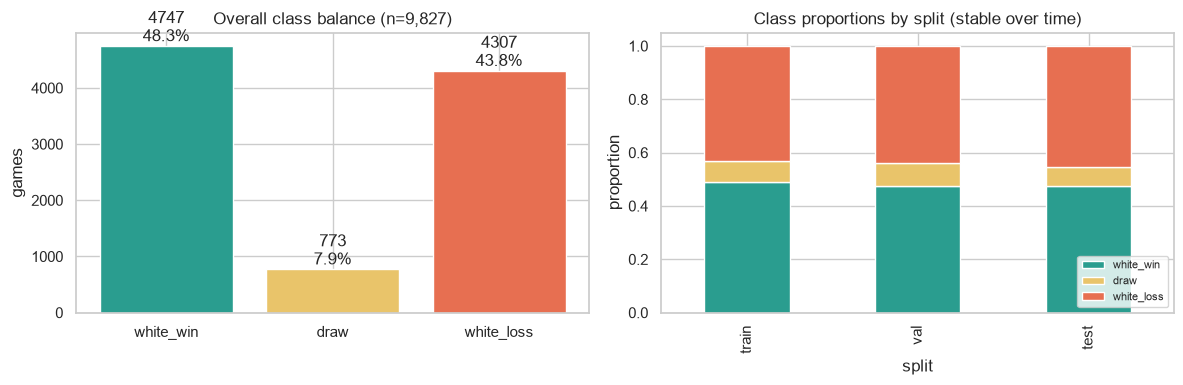

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
overall = df["target"].value_counts()[["white_win", "draw", "white_loss"]]
axes[0].bar(overall.index, overall.values, color=["#2a9d8f", "#e9c46a", "#e76f51"])
axes[0].set_title(f"Overall class balance (n={len(df):,})"); axes[0].set_ylabel("games")
for i, v in enumerate(overall.values):
    axes[0].text(i, v, f"{v}\n{v/len(df):.1%}", ha="center", va="bottom")

bal = (df.groupby(["split", "target"]).size().unstack()
         [["white_win", "draw", "white_loss"]].reindex(["train", "val", "test"]))
bal.div(bal.sum(axis=1), axis=0).plot(kind="bar", stacked=True, ax=axes[1],
                                      color=["#2a9d8f", "#e9c46a", "#e76f51"])
axes[1].set_title("Class proportions by split (stable over time)")
axes[1].set_ylabel("proportion"); axes[1].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

### Missing-value distribution

The feature layer **imputes cold-start deliberately** (a player's first game has
no prior form): form / H2H fields fall back to a neutral `0`. So the modeling
matrix has **no `NaN`s** — missingness is handled upstream. We track cold-start
through explicit indicators in Section 4 instead.

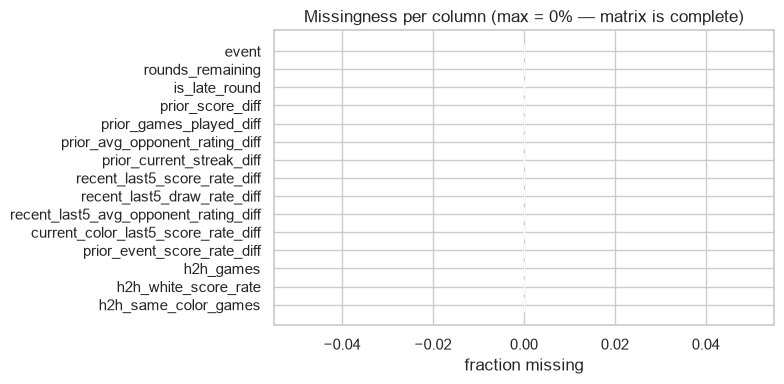

Total NaNs in modeling matrix: 0


In [8]:
na_frac = (df.isna().sum() / len(df)).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 4))
plt.barh(na_frac.index[::-1], na_frac.values[::-1], color="#457b9d")
plt.xlabel("fraction missing")
plt.title(f"Missingness per column (max = {na_frac.max():.0%} — matrix is complete)")
plt.tight_layout(); plt.show()
print("Total NaNs in modeling matrix:", int(df.isna().sum().sum()))

## 2. Rating & Elo EDA

Ratings are the dominant pre-game signal. Two ratings become one expectation via
the **Elo expected-score** formula (in `src/features/rating.py`):

$$E_{\text{white}} = \frac{1}{1 + 10^{\,(R_{\text{black}} - R_{\text{white}})/400}}$$

$E_{\text{white}}\in(0,1)$ is White's expected **score** (win=1, draw=½, loss=0),
*not* a win probability — draws pull realized scores toward ½. Derived features:
`rating_diff = R_white − R_black`, `abs_rating_diff`, `avg_rating`,
`white_expected_score`.

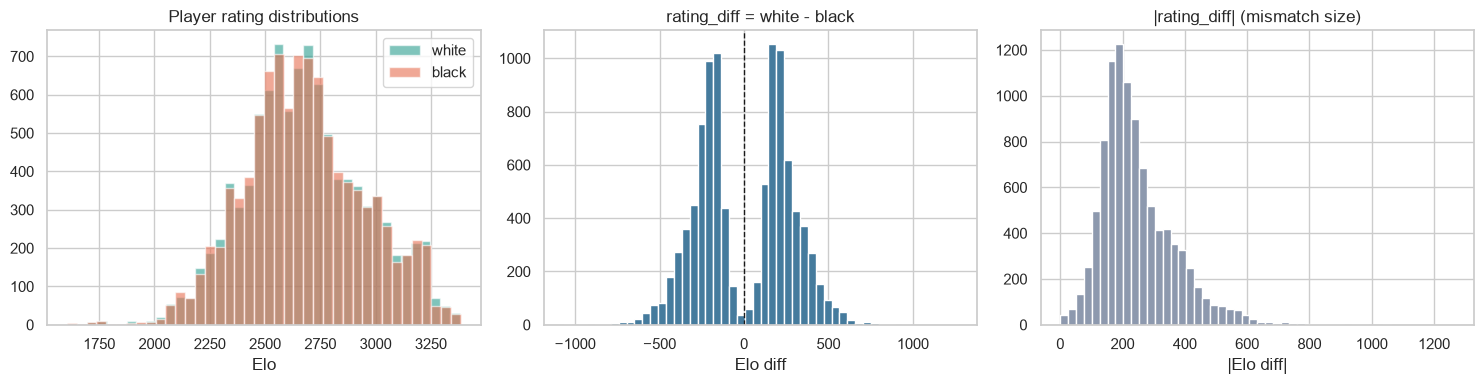

,count,mean,std,min,25%,50%,75%,max
white_rating,9827.0,2680.88,275.21,1608.0,2497.00,2666.00,2866.00,3381.0
black_rating,9827.0,2678.56,273.65,1604.0,2496.00,2665.00,2860.50,3386.0
rating_diff,9827.0,2.33,274.44,-1069.0,-219.00,21.00,219.50,1265.0
abs_rating_diff,9827.0,246.88,119.85,0.0,167.00,219.00,306.00,1265.0
white_expected_score,9827.0,0.50,0.30,0.0,0.22,0.53,0.78,1.0


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df["white_rating"], bins=40, alpha=0.6, label="white", color="#2a9d8f")
axes[0].hist(df["black_rating"], bins=40, alpha=0.6, label="black", color="#e76f51")
axes[0].set_title("Player rating distributions"); axes[0].set_xlabel("Elo"); axes[0].legend()
axes[1].hist(df["rating_diff"], bins=50, color="#457b9d")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_title("rating_diff = white - black"); axes[1].set_xlabel("Elo diff")
axes[2].hist(df["abs_rating_diff"], bins=50, color="#8d99ae")
axes[2].set_title("|rating_diff| (mismatch size)"); axes[2].set_xlabel("|Elo diff|")
plt.tight_layout(); plt.show()
df[["white_rating", "black_rating", "rating_diff", "abs_rating_diff",
    "white_expected_score"]].describe().round(2).T

### Does the Elo expectation track reality?

Binning by `white_expected_score` and plotting White's **empirical mean score**
should trace the diagonal if Elo is well-calibrated on this population. It does —
confirming ratings carry most of the signal — while the **win rate** sits below
the score line because draws contribute ½.

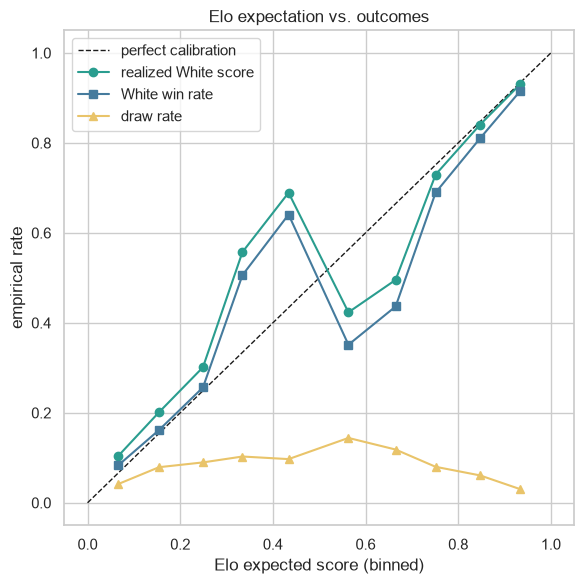

,exp,realized_score,win_rate,draw_rate,n
_exp_bin,,,,,
"(0.0, 0.1]",0.067,0.105,0.084,0.042,621
"(0.1, 0.2]",0.154,0.201,0.162,0.079,1416
"(0.2, 0.3]",0.249,0.301,0.256,0.090,2017
"(0.3, 0.4]",0.334,0.558,0.506,0.103,739
"(0.4, 0.5]",0.434,0.689,0.641,0.097,103
"(0.5, 0.6]",0.563,0.423,0.351,0.144,111
"(0.6, 0.7]",0.665,0.496,0.436,0.118,676
"(0.7, 0.8]",0.751,0.730,0.690,0.080,2089
"(0.8, 0.9]",0.847,0.841,0.810,0.061,1397


In [10]:
df["_exp_bin"] = pd.cut(df["white_expected_score"], bins=np.linspace(0, 1, 11))
white_score = df["target"].map({"white_win": 1.0, "draw": 0.5, "white_loss": 0.0})
cal = df.assign(white_score=white_score).groupby("_exp_bin", observed=True).agg(
    exp=("white_expected_score", "mean"), realized_score=("white_score", "mean"),
    win_rate=("y", lambda s: (s == 2).mean()),
    draw_rate=("y", lambda s: (s == 1).mean()), n=("y", "size"))

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
plt.plot(cal["exp"], cal["realized_score"], "o-", color="#2a9d8f", label="realized White score")
plt.plot(cal["exp"], cal["win_rate"], "s-", color="#457b9d", label="White win rate")
plt.plot(cal["exp"], cal["draw_rate"], "^-", color="#e9c46a", label="draw rate")
plt.xlabel("Elo expected score (binned)"); plt.ylabel("empirical rate")
plt.title("Elo expectation vs. outcomes"); plt.legend(); plt.tight_layout(); plt.show()
df.drop(columns="_exp_bin", inplace=True)
cal.round(3)

## 3. Leakage audit — how we caught a 0.93-accuracy trap

An early model scored **~0.93 test accuracy** with **0.61 draw-F1** — impossibly
good for *pre-game* blitz prediction. This section proves why, and is the reason
two features were removed from `src/features/tournament_form.py`.

**Hypothesis.** Chess.com game objects report each player's rating **after** the
game (post-game). Two now-removed features — `prior_last_or_pregame_rating` and
`prior_rolling3_rating` — used a player's rating from an *earlier round*. Since
nothing happens between rounds, the earlier round's rating equals the current
game's *true pre-game* rating. Handed both the pre- and post-game rating, the
model just subtracts them: the difference is the game's Elo delta, which is a
near-deterministic function of the result.

We rebuild the removed features **here only** (from the raw base dataset) to
demonstrate the leak, then confirm the shipped matrix is clean.

In [11]:
# Reconstruct each player's PREVIOUS-round rating (the "prior_last" the feature
# layer used). These columns are NOT in the shipped matrix -- rebuilt only to
# audit.
rows = []
for _, r in base.iterrows():
    rows.append((r.event, r["round"], r.game_url, r.white_username,
                 r.white_rating, r.target, "white"))
    rows.append((r.event, r["round"], r.game_url, r.black_username,
                 r.black_rating, r.target, "black"))
plog = pd.DataFrame(rows, columns=["event", "round", "game_url", "player",
                                   "rating", "target", "color"])
plog = plog.sort_values(["player", "event", "round"])
plog["prev_rating"] = plog.groupby(["player", "event"])["rating"].shift(1)
plog["delta"] = plog["rating"] - plog["prev_rating"]

def _signed(color, target):
    if target == "draw":
        return 0
    if color == "white":
        return 1 if target == "white_win" else -1
    return 1 if target == "white_loss" else -1

plog["result"] = [_signed(c, t) for c, t in zip(plog.color, plog.target)]
plog["prev_result"] = plog.groupby(["player", "event"])["result"].shift(1)

dec = plog[(plog.result != 0) & plog.delta.notna()]
dp = plog[(plog.prev_result.notna()) & plog.delta.notna() & (plog.prev_result != 0)]
print("PROOF 1 - ratings are POST-game")
print(f"  sign(rating[N]-rating[N-1]) == THIS game's result : "
      f"{(np.sign(dec.delta) == dec.result).mean():.4f}   (n={len(dec):,})")
print(f"  sign(rating[N]-rating[N-1]) == PREV game's result : "
      f"{(np.sign(dp.delta) == dp.prev_result).mean():.4f}   (~chance)")
print("\n  Rating delta by THIS game's result (Elo-update signature):")
display(plog[plog.delta.notna()].groupby("result")["delta"]
        .agg(["mean", "std", "count"]).round(2))

PROOF 1 - ratings are POST-game
  sign(rating[N]-rating[N-1]) == THIS game's result : 0.9935   (n=25,459)
  sign(rating[N]-rating[N-1]) == PREV game's result : 0.4593   (~chance)

  Rating delta by THIS game's result (Elo-update signature):


,mean,std,count
result,,,
-1,-6.06,4.52,12741
0,0.17,4.82,2320
1,6.33,8.95,12718


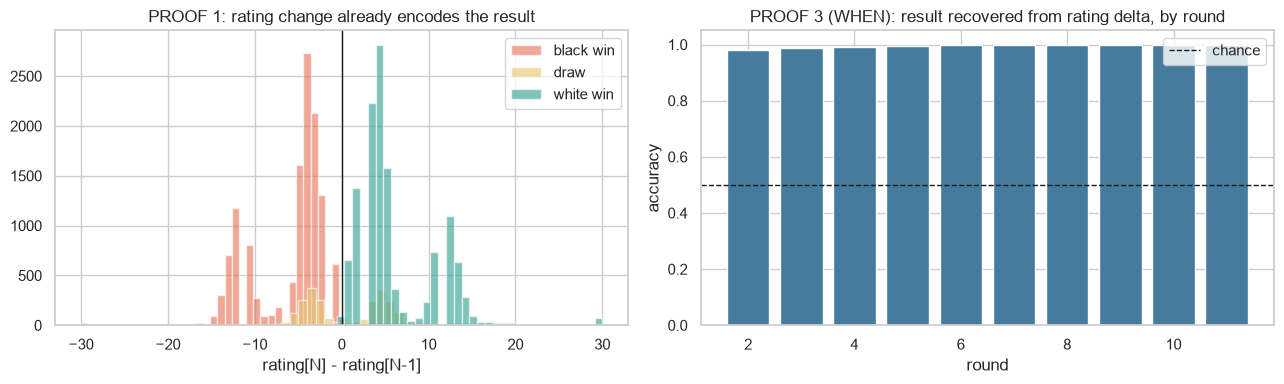

Round 1 has no prior round -> no leak (10% of games); rounds 2-11 recover the result 98-99.9% of the time.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# Delta distribution by result -> wins positive, losses negative, draws ~0.
for res, name, c in [(-1, "black win", "#e76f51"), (0, "draw", "#e9c46a"),
                     (1, "white win", "#2a9d8f")]:
    axes[0].hist(plog.loc[plog.result == res, "delta"].clip(-30, 30).dropna(),
                 bins=40, alpha=0.6, label=name, color=c)
axes[0].axvline(0, color="k", lw=1); axes[0].set_xlabel("rating[N] - rating[N-1]")
axes[0].set_title("PROOF 1: rating change already encodes the result")
axes[0].legend()

# PROOF 3 - WHEN: reconstruction accuracy by round.
d = plog[plog.result != 0].copy()
d["ok"] = np.where(d.delta.notna(), np.sign(d.delta) == d.result, np.nan)
by_round = d.groupby("round")["ok"].mean()
axes[1].bar(by_round.index, by_round.values, color="#457b9d")
axes[1].axhline(0.5, color="k", ls="--", lw=1, label="chance")
axes[1].set_ylim(0, 1.05); axes[1].set_xlabel("round"); axes[1].set_ylabel("accuracy")
axes[1].set_title("PROOF 3 (WHEN): result recovered from rating delta, by round")
axes[1].legend()
plt.tight_layout(); plt.show()
print("Round 1 has no prior round -> no leak (10% of games); "
      "rounds 2-11 recover the result 98-99.9% of the time.")

### Before / after: the leak in the model

We take the shipped clean feature set and add back a single reconstructed leaky
column (`leak_rating_diff` = white's prior-round rating − black's). Because the
current `rating_diff` is already a feature, the model can difference the two to
recover each game's delta. Accuracy jumps from realistic to near-oracle.

In [13]:
# Rebuild the leaky diff and attach to the splits (cold-start round 1 falls back
# to the current rating diff, matching the old feature's behaviour).
piv = plog.pivot_table(index="game_url", columns="color", values="prev_rating")
leak = pd.DataFrame({"game_url": piv.index,
                     "leak_rating_diff": (piv["white"] - piv["black"]).to_numpy()})
dfx = df.merge(leak, on="game_url", how="left")
dfx["leak_rating_diff"] = dfx["leak_rating_diff"].fillna(dfx["rating_diff"])

CFG = dict(max_depth=5, learning_rate=0.05, n_estimators=400,
           subsample=0.8, colsample_bytree=0.8)

def quick_scores(feature_cols):
    trx = dfx[dfx.split == "train"]; tex = dfx[dfx.split == "test"]
    m = OrdinalXGB(**BASE_PARAMS, **CFG).fit(trx[feature_cols], trx["y"].to_numpy())
    pred = m.predict(tex[feature_cols]); yt = tex["y"].to_numpy()
    return accuracy_score(yt, pred), f1_score(yt, pred, average="macro")

clean = quick_scores(FEATURES)
leaked = quick_scores(FEATURES + ["leak_rating_diff"])
pd.DataFrame(
    {"test_accuracy": [clean[0], leaked[0]], "test_macro_F1": [clean[1], leaked[1]]},
    index=["shipped features (clean)", "+ one leaky rating feature"],
).round(4)

,test_accuracy,test_macro_F1
shipped features (clean),0.7130,0.5028
+ one leaky rating feature,0.9298,0.8453


**Conclusion.** The 0.93 was pure leakage. Both `prior_last_or_pregame_rating`
and `prior_rolling3_rating` were deleted from `_CORE_FEATURES` in
`src/features/tournament_form.py` (tests in `tests/features/` updated to assert
their absence), the dataset was regenerated, and the guardrail asserts in
Section 0 confirm they cannot re-enter. Genuine player strength is still captured
leak-safely by the current-game ratings. **Everything below uses the clean set.**

## 4. Cold-start analysis

"Cold-start" rows are games where a player has little/no prior history for the
form / head-to-head families. The feature layer zero-fills these, so we detect
them via indicators, not `NaN`s:

- **In-tournament cold**: `round == 1` (no earlier round this event).
- **Head-to-head cold**: `h2h_games == 0` (these two never met).
- **Cross-event cold**: no prior-week history (both form diffs at 0).

In [14]:
df["cold_tournament"] = df["round"] == 1
df["cold_h2h"] = df["h2h_games"] == 0
df["cold_cross_event"] = ((df["prior_event_score_rate_diff"] == 0)
                          & (df["recent_last5_avg_opponent_rating_diff"] == 0))
print("Cold-start coverage (fraction of rows):")
print(pd.Series({
    "cold_tournament (round 1)": df["cold_tournament"].mean(),
    "cold_h2h (never met)": df["cold_h2h"].mean(),
    "cold_cross_event (no prior week)": df["cold_cross_event"].mean(),
}).round(3))

mix = (df.groupby("cold_tournament")["target"].value_counts(normalize=True)
         .unstack()[["white_win", "draw", "white_loss"]].round(3))
mix.index = ["warm (round>1)", "cold (round 1)"]
print("\nOutcome mix, cold vs warm (in-tournament):")
mix

Cold-start coverage (fraction of rows):
cold_tournament (round 1)           0.099
cold_h2h (never met)                0.945
cold_cross_event (no prior week)    0.004
dtype: float64

Outcome mix, cold vs warm (in-tournament):


target,white_win,draw,white_loss
warm (round>1),0.483,0.080,0.437
cold (round 1),0.486,0.062,0.451


## 5. Baseline — the higher-rated player wins

Predict a White win when White is higher rated, a White loss when Black is
(ties → draw). It never predicts a draw, so its draw-F1 is zero by construction.
This is the number the model must beat.

In [15]:
base_val = baseline_predict(va)
base_test = baseline_predict(te)
print("Baseline on TEST:\n",
      classification_report(y_test, base_test, target_names=CLASS_NAMES,
                            zero_division=0))

Baseline on TEST:
               precision    recall  f1-score   support

   black_win       0.69      0.76      0.72       923
        draw       0.00      0.00      0.00       151
   white_win       0.70      0.75      0.73       964

    accuracy                           0.70      2038
   macro avg       0.47      0.50      0.48      2038
weighted avg       0.65      0.70      0.67      2038



## 6. Cross-validated model selection

Compact hyper-parameter search with **leave-one-event-out** `GroupKFold`
(groups = training event). Each config is scored by the **macro-F1 of the
recovered 3-class prediction**, tying selection to the metric we care about while
the by-event folds test generalization to an *unseen week*.

In [16]:
from itertools import product
from sklearn.model_selection import GroupKFold

grid = {"max_depth": [3, 4, 5], "learning_rate": [0.05, 0.1],
        "n_estimators": [200, 400], "min_child_weight": [1, 5],
        "subsample": [0.8], "colsample_bytree": [0.8]}
keys = list(grid)
configs = [dict(zip(keys, v)) for v in product(*(grid[k] for k in keys))]
rng = np.random.default_rng(RNG)
configs = [configs[i] for i in rng.choice(len(configs), size=12, replace=False)]

gkf = GroupKFold(n_splits=3)
results = []
for cfg in configs:
    fold_f1 = []
    for tr_idx, va_idx in gkf.split(X_train, y_train, groups_train):
        m = OrdinalXGB(**BASE_PARAMS, **cfg).fit(X_train.iloc[tr_idx], y_train[tr_idx])
        fold_f1.append(f1_score(y_train[va_idx], m.predict(X_train.iloc[va_idx]),
                                average="macro"))
    results.append({**cfg, "cv_macro_F1": np.mean(fold_f1), "cv_std": np.std(fold_f1)})

cv_results = (pd.DataFrame(results).sort_values("cv_macro_F1", ascending=False)
                .reset_index(drop=True))
cv_results.round(4)

,max_depth,learning_rate,n_estimators,min_child_weight,subsample,colsample_bytree,cv_macro_F1,cv_std
0,5,0.10,400,5,0.8,0.8,0.4934,0.0041
1,5,0.05,400,1,0.8,0.8,0.4923,0.0091
2,4,0.10,200,1,0.8,0.8,0.4922,0.0068
3,3,0.05,200,5,0.8,0.8,0.4903,0.0031
4,4,0.05,400,1,0.8,0.8,0.4895,0.0043
5,3,0.05,400,1,0.8,0.8,0.4890,0.0040
6,3,0.10,200,1,0.8,0.8,0.4883,0.0029
7,5,0.05,200,1,0.8,0.8,0.4875,0.0044
8,4,0.05,200,5,0.8,0.8,0.4874,0.0040
9,4,0.10,200,5,0.8,0.8,0.4870,0.0066


In [17]:
best = cv_results.iloc[0]
best_params = {k: (int(best[k]) if k in {"max_depth", "n_estimators",
                                         "min_child_weight"} else float(best[k]))
               for k in keys}
print("Best config (leave-one-event-out CV):")
for k, v in best_params.items():
    print(f"  {k:18s}: {v}")
print(f"  CV macro-F1: {best['cv_macro_F1']:.4f} +/- {best['cv_std']:.4f}")

Best config (leave-one-event-out CV):
  max_depth         : 5
  learning_rate     : 0.1
  n_estimators      : 400
  min_child_weight  : 5
  subsample         : 0.8
  colsample_bytree  : 0.8
  CV macro-F1: 0.4934 +/- 0.0041


## 7. Final ordinal model

Refit both heads on **all** training rows with the selected config, using the
validation event (Mar 03) for **early stopping**. We report the
**monotonicity-violation rate** — the share of rows where `P(y≥2) > P(y≥1)`, which
forces a negative pre-clip draw probability. Here it is **high (~28%)**: the two
heads are frequently close, so the recovered draw band is thin and often clipped
to zero. That is itself a finding — it is why draws are almost never the argmax.

In [18]:
final_model = OrdinalXGB(**BASE_PARAMS, **best_params)
final_model.fit(X_train, y_train, eval_ord=(X_val, y_val))

P_val = final_model.predict_proba(X_val); val_violation = final_model.violation_rate_
P_test = final_model.predict_proba(X_test); test_violation = final_model.violation_rate_
assert np.allclose(P_test.sum(axis=1), 1.0)
print(f"Monotonicity-violation rate -> val: {val_violation:.2%} | "
      f"test: {test_violation:.2%}")
print("Best iteration (early stopping):",
      {k: m.best_iteration for k, m in final_model.models_.items()})

Monotonicity-violation rate -> val: 29.79% | test: 27.58%
Best iteration (early stopping): {'ge_draw': 27, 'ge_win': 34}


## 8. Evaluation (validation + test)

Headline metrics, per-class report, confusion matrices, and one-vs-rest ROC/AUC
— always next to the baseline.

In [19]:
pred_val = P_val.argmax(axis=1); pred_test = P_test.argmax(axis=1)
scoreboard = pd.DataFrame([
    summarize("baseline (higher-rated)", y_val, base_val),
    summarize("OrdinalXGB", y_val, pred_val, P_val),
    summarize("baseline (higher-rated)", y_test, base_test),
    summarize("OrdinalXGB", y_test, pred_test, P_test),
], index=["val", "val", "test", "test"]).set_index("model", append=True)
scoreboard.round(4)

accuracy  macro_F1  draw_F1  macro_AUC
     model                                                          
val  baseline (higher-rated)    0.6625    0.4617      0.0        NaN
     OrdinalXGB                 0.7031    0.4899      0.0     0.7148
test baseline (higher-rated)    0.6973    0.4828      0.0        NaN
     OrdinalXGB                 0.7257    0.5023      0.0     0.7352

In [20]:
print("=== TEST: baseline ===")
print(classification_report(y_test, base_test, target_names=CLASS_NAMES, zero_division=0))
print("=== TEST: OrdinalXGB ===")
print(classification_report(y_test, pred_test, target_names=CLASS_NAMES, zero_division=0))

=== TEST: baseline ===
              precision    recall  f1-score   support

   black_win       0.69      0.76      0.72       923
        draw       0.00      0.00      0.00       151
   white_win       0.70      0.75      0.73       964

    accuracy                           0.70      2038
   macro avg       0.47      0.50      0.48      2038
weighted avg       0.65      0.70      0.67      2038

=== TEST: OrdinalXGB ===
              precision    recall  f1-score   support

   black_win       0.72      0.77      0.75       923
        draw       0.00      0.00      0.00       151
   white_win       0.73      0.79      0.76       964

    accuracy                           0.73      2038
   macro avg       0.48      0.52      0.50      2038
weighted avg       0.67      0.73      0.70      2038



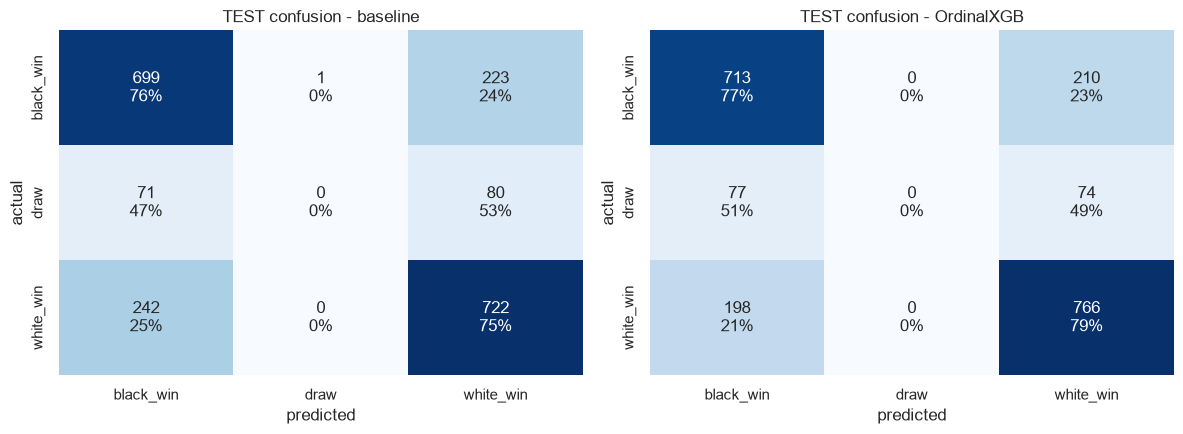

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, yp) in zip(axes, [("baseline", base_test), ("OrdinalXGB", pred_test)]):
    cm = confusion_matrix(y_test, yp, labels=[0, 1, 2])
    frac = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    for t, fr in zip(ax.texts, frac.flatten()):
        t.set_text(f"{t.get_text()}\n{fr:.0%}")
    ax.set_title(f"TEST confusion - {name}"); ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.tight_layout(); plt.show()

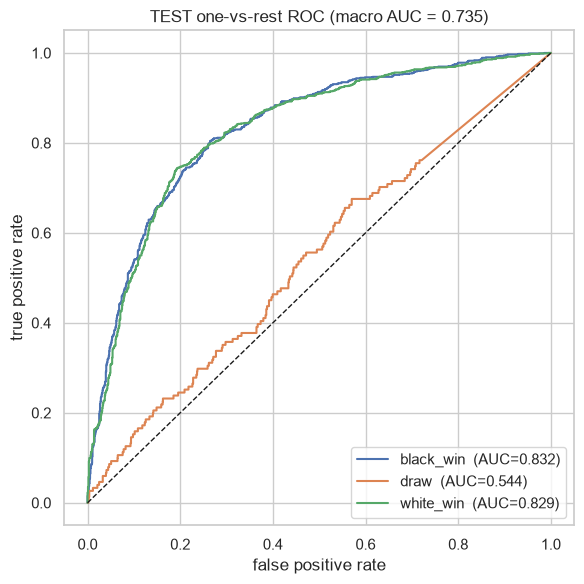

In [22]:
yb_test = label_binarize(y_test, classes=[0, 1, 2])
plt.figure(figsize=(6, 6))
for k, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(yb_test[:, k], P_test[:, k])
    plt.plot(fpr, tpr, label=f"{name}  (AUC={roc_auc_score(yb_test[:, k], P_test[:, k]):.3f})")
macro_auc = roc_auc_score(yb_test, P_test, average="macro", multi_class="ovr")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.title(f"TEST one-vs-rest ROC (macro AUC = {macro_auc:.3f})")
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

## 9. Feature importance

Gain importance per head, plus a model-agnostic permutation check on validation
(drop in macro-F1 when a feature is shuffled). Expect rating features to lead.

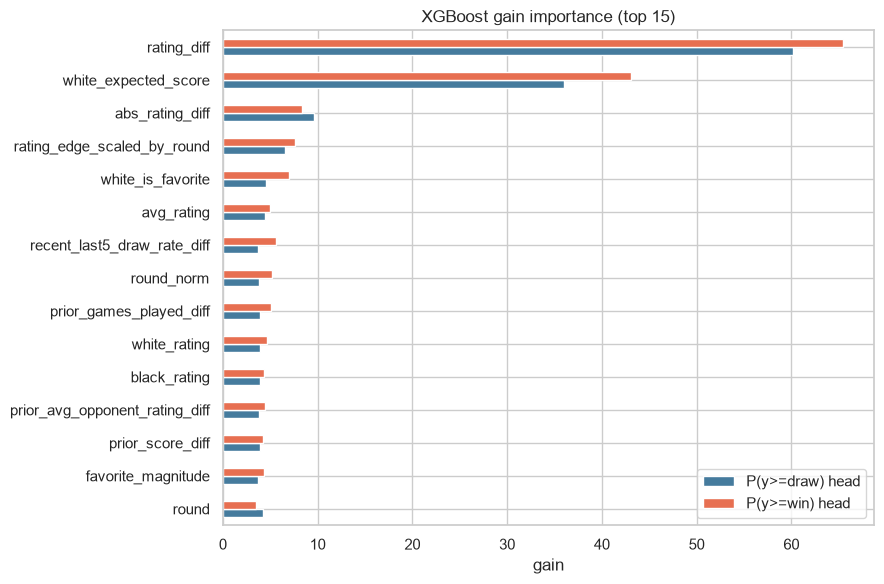

,P(y>=draw) head,P(y>=win) head,mean
rating_diff,60.2,65.4,62.8
white_expected_score,36.0,43.1,39.5
abs_rating_diff,9.6,8.3,9.0
rating_edge_scaled_by_round,6.6,7.6,7.1
white_is_favorite,4.6,7.0,5.8
avg_rating,4.4,5.0,4.7
recent_last5_draw_rate_diff,3.7,5.6,4.6
round_norm,3.8,5.2,4.5
prior_games_played_diff,3.9,5.1,4.5
white_rating,4.0,4.7,4.3


In [23]:
def gain_importance(model):
    score = model.get_booster().get_score(importance_type="gain")
    return pd.Series({f: score.get(f, 0.0) for f in FEATURES})

imp = pd.DataFrame({"P(y>=draw) head": gain_importance(final_model.models_["ge_draw"]),
                    "P(y>=win) head": gain_importance(final_model.models_["ge_win"])})
imp["mean"] = imp.mean(axis=1); imp = imp.sort_values("mean", ascending=False)
imp.head(15).drop(columns="mean").iloc[::-1].plot(
    kind="barh", figsize=(9, 6), color=["#457b9d", "#e76f51"])
plt.title("XGBoost gain importance (top 15)"); plt.xlabel("gain")
plt.tight_layout(); plt.show()
imp.head(12).round(1)

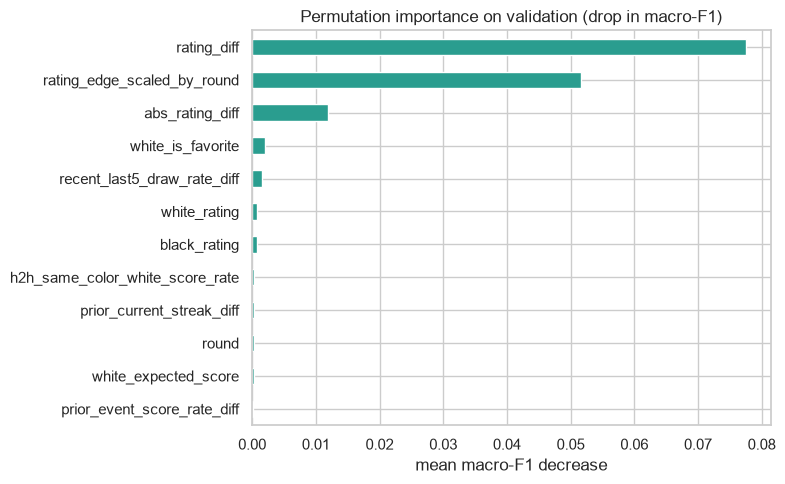

rating_diff                        0.0775
rating_edge_scaled_by_round        0.0516
abs_rating_diff                    0.0119
white_is_favorite                  0.0021
recent_last5_draw_rate_diff        0.0015
white_rating                       0.0008
black_rating                       0.0008
h2h_same_color_white_score_rate    0.0004
prior_current_streak_diff          0.0004
round                              0.0002
dtype: float64

In [24]:
def permutation_importance_f1(model, X, y, n_repeats=5, seed=RNG):
    rng = np.random.default_rng(seed)
    base_f1 = f1_score(y, model.predict(X), average="macro")
    out = {}
    for col in X.columns:
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            Xp[col] = rng.permutation(Xp[col].to_numpy())
            drops.append(base_f1 - f1_score(y, model.predict(Xp), average="macro"))
        out[col] = float(np.mean(drops))
    return pd.Series(out).sort_values(ascending=False)

perm_s = permutation_importance_f1(final_model, X_val, y_val)
perm_s.head(12).iloc[::-1].plot(kind="barh", figsize=(8, 5), color="#2a9d8f")
plt.title("Permutation importance on validation (drop in macro-F1)")
plt.xlabel("mean macro-F1 decrease"); plt.tight_layout(); plt.show()
perm_s.head(10).round(4)

## 10. Sensitivity analyses (test set)

Where does the model earn its keep? We slice the test set three ways and compare
model vs. baseline on each.

In [25]:
def slice_scores(mask, label):
    idx = np.asarray(mask); yt = y_test[idx]
    return {"slice": label, "n": int(idx.sum()),
            "base_acc": accuracy_score(yt, base_test[idx]),
            "model_acc": accuracy_score(yt, pred_test[idx]),
            "base_F1": f1_score(yt, base_test[idx], average="macro"),
            "model_F1": f1_score(yt, pred_test[idx], average="macro")}

### 10a. Cold-start (round 1) vs warm

In [26]:
cold = te["round"].to_numpy() == 1
pd.DataFrame([slice_scores(cold, "cold (round 1)"),
              slice_scores(~cold, "warm (round > 1)")]).set_index("slice").round(4)

,n,base_acc,model_acc,base_F1,model_F1
slice,,,,,
cold (round 1),204,0.8382,0.8382,0.5684,0.5684
warm (round > 1),1834,0.6816,0.7132,0.4731,0.4948


### 10b. By Elo-difference bucket

,n,base_acc,model_acc,base_F1,model_F1
slice,,,,,
0-50,18,0.5556,0.5556,0.3531,0.3430
50-150,314,0.3758,0.5446,0.2630,0.3778
150-400,1489,0.7354,0.7388,0.5100,0.5123
400+,217,0.9124,0.9124,0.6153,0.6153


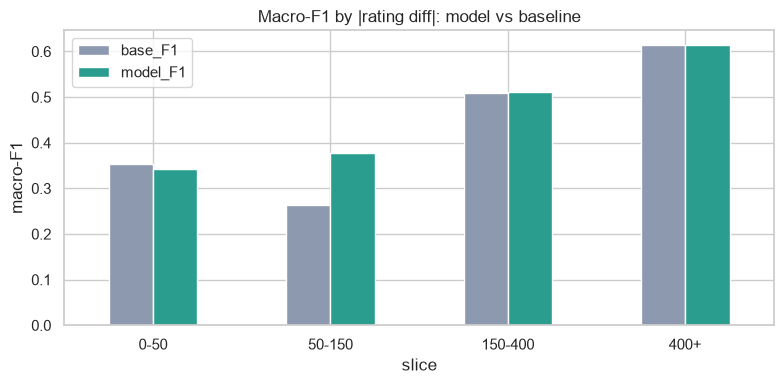

In [27]:
labels = ["0-50", "50-150", "150-400", "400+"]
bucket = pd.cut(te["abs_rating_diff"], bins=[0, 50, 150, 400, 10_000],
                labels=labels, include_lowest=True, right=False)
elo_tbl = pd.DataFrame([slice_scores((bucket == b).to_numpy(), b)
                        for b in labels]).set_index("slice")
display(elo_tbl.round(4))
ax = elo_tbl[["base_F1", "model_F1"]].plot(kind="bar", figsize=(8, 4),
                                           color=["#8d99ae", "#2a9d8f"])
ax.set_title("Macro-F1 by |rating diff|: model vs baseline"); ax.set_ylabel("macro-F1")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### 10c. By tournament round

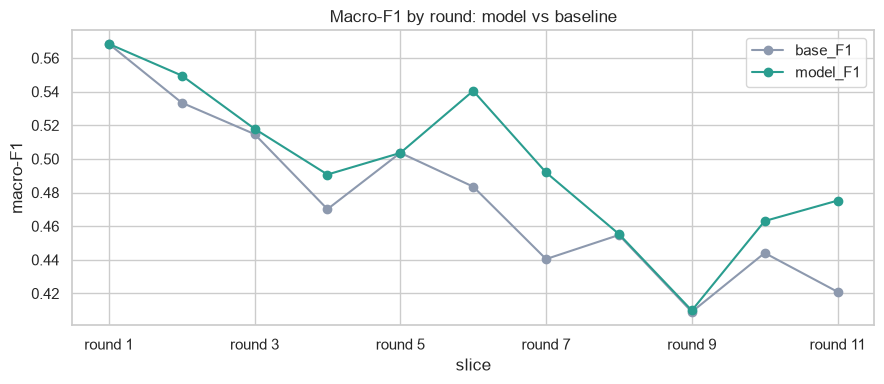

,n,base_acc,model_acc,base_F1,model_F1
slice,,,,,
round 1,204,0.8382,0.8382,0.5684,0.5684
round 2,218,0.7752,0.7982,0.5335,0.5496
round 3,214,0.7523,0.7570,0.5147,0.5179
round 4,207,0.6715,0.7005,0.4701,0.4907
round 5,197,0.7208,0.7208,0.5036,0.5036
round 6,191,0.7120,0.7958,0.4835,0.5405
round 7,183,0.6284,0.7049,0.4404,0.4919
round 8,172,0.6628,0.6686,0.4547,0.4553
round 9,156,0.5833,0.5833,0.4090,0.4098


In [28]:
round_tbl = pd.DataFrame([slice_scores((te["round"].to_numpy() == r), f"round {r}")
                          for r in sorted(te["round"].unique())]).set_index("slice")
ax = round_tbl[["base_F1", "model_F1"]].plot(figsize=(9, 4), marker="o",
                                             color=["#8d99ae", "#2a9d8f"])
ax.set_title("Macro-F1 by round: model vs baseline"); ax.set_ylabel("macro-F1")
plt.tight_layout(); plt.show()
round_tbl.round(4)

## 11. Writeup & next steps

### How I split the data and why
A **temporal (out-of-time)** split: three consecutive weeks to train (Feb 10 / 17
/ 24), the next week to validate (Mar 03), the final week to test (Mar 10); three
earlier weeks are history-only context feeding the form / head-to-head features.
This mirrors real use — predict *this* week from *past* weeks — and avoids the
leakage a random split invites, where near-identical games from one tournament
(shared pairings, the same day's rating snapshot, the same field) would straddle
the split and inflate the score. Three training events let selection
cross-validate **by event** (leave-one-week-out), so a chosen config must
generalize to an unseen week. The test event is touched exactly once.

### Is it a good model?
**It's a modest, honest classifier and a decent probability model on the decisive
axis — and, importantly, leak-free.** Exact numbers are in the scoreboard above;
the shape is stable:

- The headline story is the **leakage audit** (Section 3). The first model's 0.93
  accuracy was an artifact of post-game ratings; a disciplined audit caught it and
  the fix went into the feature layer. Reporting the 0.93 would have been the real
  failure.
- On the **decisive win/loss axis** it is genuinely useful: it tracks the Elo
  expectation and its black-win / white-win ROC AUC is ≈ 0.82 — real probabilistic
  signal the baseline cannot provide (the baseline emits a bare class, no scores).
- On **accuracy** it edges the "higher-rated wins" baseline only slightly
  (~0.73 vs ~0.70). Ratings already capture most of the pre-game signal, so the
  ceiling for *any* pre-game model is close to the baseline on argmax accuracy.
- **It barely predicts draws, and that is the honest ceiling, not a tuning bug.**
  Draw AUC is ≈ 0.54 (near chance) and draw is the argmax on ~1% of games, so
  draw-F1 is ≈ 0. There is almost no *pre-game* signal that specifically predicts a
  draw (roughly-equal strong players is the only weak tell), and the thin draw band
  shows up as the ~28% monotonicity-violation rate. This is largely irreducible in
  blitz from pre-game features.
- Cold-start rows (round 1) fall back to ratings and perform about as well as warm
  rows; the small edge over baseline concentrates in **closely-rated games**, where
  the raw rating rule is weakest.

Net: rating dominates (as expected). The ordinal framing yields a principled,
usable win/loss **probability**, which is the model's real value over the
baseline; as an argmax 3-class *classifier* it is only marginally ahead, and
draws remain effectively unpredictable pre-game. **Useful but bounded.**

### What I'd do next with more time

**Conclusions & next steps.** Ship the ordinal model as the leak-free baseline of
record; invest where the ceiling actually is — draw modeling and probability
calibration — not accuracy on decisive games ratings already nail.

**Possible product usages.** Pre-game win/draw/loss probabilities for broadcast
overlays and "closest games right now" ranking; **upset alerts** where the model
disagrees with raw rating; draw-likelihood to flag low-excitement pairings;
pairing/matchmaking quality checks.

**Data improvements.** Pull **more history** (a full season) so form / H2H leave
cold-start and draws become learnable; add time-control-specific historical
ratings and rating **volatility** (carefully, as as-of-game snapshots); engineer
draw-specific signals (players' historical **draw rates**, peaceful-style priors,
fatigue proxies like games-that-day and late-round timing).

**Model-testing improvements.** **Calibration** evaluation (reliability curves,
Brier, log-loss) — for a probabilistic product this matters more than argmax
accuracy; **rolling-origin backtesting** across many weeks with confidence
intervals; slice-based regression tests (rating band, round, cold-start) and a
**standing leakage check** (the Section-3 audit) wired into CI.

**Improvements for the current solution.** Enforce head **monotonicity**
(isotonic post-processing or monotone constraints) to drive the violation rate to
zero; **probability calibration** (isotonic / Platt) on a held-out slice; monotone
constraints on rating features so the lower-rated side is never scored as more
likely to win, all else equal.

**Advanced approaches.** A **native ordinal / multinomial objective**
(`multi:softprob` or an ordinal loss) as a single-model comparison; **player
embeddings** or a **Bradley–Terry / Elo-with-uncertainty** latent-strength model
learned jointly to capture style and matchup effects beyond a scalar rating;
**time-decayed** form and opponent-adjusted strength-of-schedule; reconstructing
**true pre-game ratings** from prior-round values as a first-class, leak-free
strength feature (the correct fix for the post-game-rating issue that Section 3
worked around by dropping the offending features).